1. Diagnostic & Choix Techniques
Réduction de Dimensionnalité (PCA vs t-SNE/UMAP) :

Choix validé : PCA (Principal Component Analysis).

Justification : Sur des données tabulaires médicales (30 features corrélées comme rayon, périmètre, surface), la PCA est idéale pour éliminer la multicollinéarité (redondance) avant un modèle linéaire comme le Perceptron. t-SNE ou UMAP sont excellents pour la visualisation mais conservent mal les distances globales nécessaires à l'inférence d'un classifieur linéaire simple.

Configuration : Conserver 95% de la variance est la norme en bio-statistiques pour ne pas perdre de biomarqueurs subtils.

Architecture Modèle (Perceptron) :

État actuel : Perceptron monocouche (SLP). Il s'agit d'un classifieur linéaire.

Critique : Le dataset BCW est linéairement séparable à haut degré, mais un SLP peut converger difficilement si les classes se chevauchent (données non séparables).

Recommandation : Conserver le SLP pour la baseline. Si le F1-Score stagne, passer à un MLP (Multi-Layer Perceptron) avec activation ReLU pour capturer les non-linéarités.

Cellule 1-2 : Import & Chargement

Technique : Chargement des bibliothèques. Le sys.path.insert indique l'utilisation d'un module local perceptron.py.

Vulgarisation : On prépare l'établi et on sort les outils. On charge le "dossier patient" (CSV) en mémoire.

Note Bio-info : Les features (radius, texture, etc.) sont issues de l'analyse d'images de cytopathologie (FNA).

In [1]:
import sys
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Ajouter le répertoire parent au path pour importer perceptron
sys.path.insert(0, str(pathlib.Path().resolve().parent))
from perceptron import Perceptron

DATAFRAME = '../data/bcw_simple_cleaning.csv'

In [2]:
df = pd.read_csv(DATAFRAME)
df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


Cellule 3-4 : Préparation & Split

Technique : Conversion Pandas $\to$ Numpy. train_test_split avec stratify=y.

Vulgarisation : On sépare les données en deux tas : un pour réviser (Train), un pour l'examen final (Test). Le "stratify" assure qu'on a la même proportion de cancers dans les deux tas (ne pas avoir que des cas sains à l'examen).

Analyse : 455 cas d'entraînement, 114 de test. Ratio 80/20 standard.

In [3]:
X = df.drop(columns=["target"]).values
y = df["target"].values  # 1=Malignant, 0=Benign

print(X.shape, y.shape)

(569, 30) (569,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((455, 30), (114, 30), (455,), (114,))

Cellule 5 : Standardisation (StandardScaler)

Technique : Normalisation Z-score : $z = \frac{x - \mu}{\sigma}$. Centre sur 0, écart-type de 1.

Vulgarisation : On met tout le monde sur la même échelle. Sans ça, la "Surface" (valeur ~1000) écraserait la "Fractal Dimension" (valeur ~0.05) lors de l'apprentissage.

Impératif : Le scaler est "fit" sur le Train et "transform" sur le Test. C'est respecté ici (pas de fuite de données).

In [5]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Cellule 6-7 : PCA (Réduction de Dimension)

Technique : Décomposition en valeurs propres de la matrice de covariance. Projection orthogonale.

Vulgarisation : On cherche l'angle sous lequel l'ombre de l'objet donne le plus d'informations. On passe de 30 colonnes à 10 colonnes (pour 95% de variance).

Résultat : Le graphe 2D montre une séparation assez nette entre Bénin (bleu) et Malin, confirmant qu'un modèle linéaire (Perceptron) performera bien.

PCA2 variance totale: 0.631387776559559


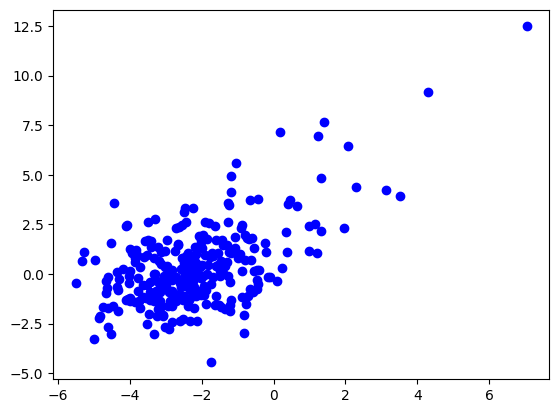

In [6]:
pca2 = PCA(n_components=2, random_state=42)
X_train_pca2 = pca2.fit_transform(X_train_s)
X_test_pca2 = pca2.transform(X_test_s)

print("PCA2 variance totale:", pca2.explained_variance_ratio_.sum())
plt.plot(X_train_pca2[y_train == 0][:, 0], X_train_pca2[y_train == 0][:, 1], "bo", label="Benign")

In [7]:
# PCA 95% (modèle)
pca95 = PCA(n_components=0.95, random_state=42)
X_train_pca = pca95.fit_transform(X_train_s)
X_test_pca = pca95.transform(X_test_s)

print("Nb composantes (95%):", pca95.n_components_)
print("Variance totale:", pca95.explained_variance_ratio_.sum())

Nb composantes (95%): 10
Variance totale: 0.9520691014391001


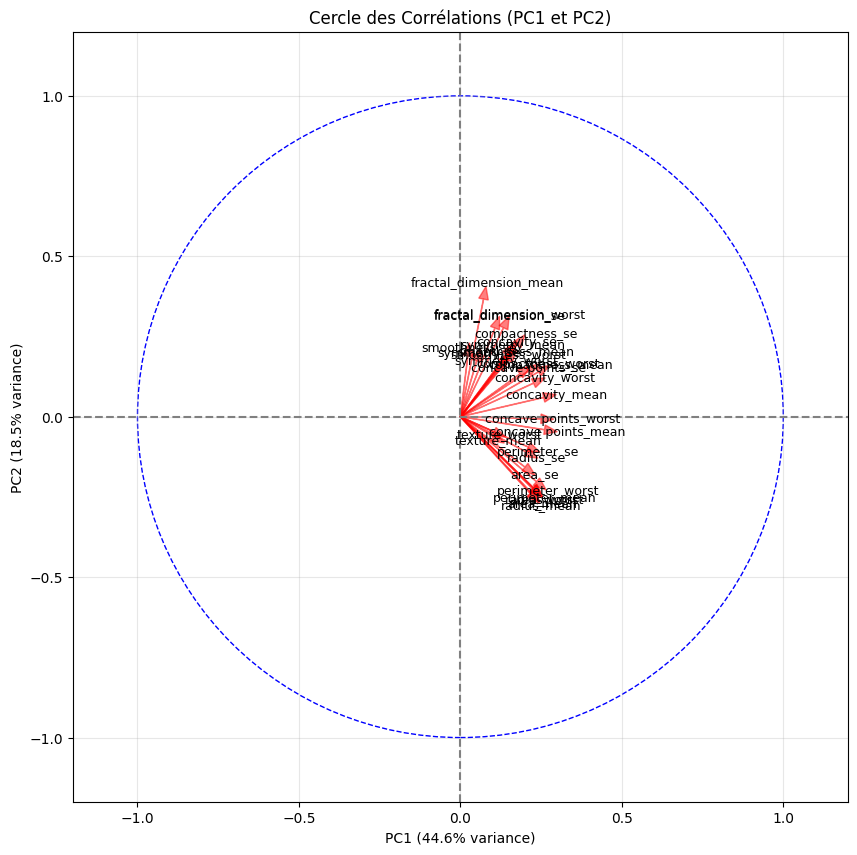

In [19]:
def plot_correlation_circle(pca, feature_names, components=[0, 1]):
    """
    Trace le cercle des corrélations pour les composantes spécifiées.
    """
    d1, d2 = components
    
    # Coordonnées des variables (Loadings)
    # pca.components_ est de forme (n_components, n_features)
    # On prend la ligne d1 (PC1) et la ligne d2 (PC2)
    pcs = pca.components_[[d1, d2], :].T 
    
    plt.figure(figsize=(10, 10))
    
    # Dessiner les flèches
    for i, (x, y) in enumerate(pcs):
        # On ne trace que les flèches assez longues pour la lisibilité
        if x**2 + y**2 > 0.01: 
            plt.arrow(0, 0, x, y, head_width=0.03, head_length=0.04, fc='r', ec='r', alpha=0.5)
            # Ajouter le nom de la variable un peu plus loin que la flèche
            plt.text(x * 1.15, y * 1.15, feature_names[i], color='black', ha='center', va='center', fontsize=9)

    # Dessiner le cercle unité
    circle = plt.Circle((0, 0), 1, facecolor='none', edgecolor='b', linestyle='--')
    plt.gca().add_artist(circle)

    # Lignes des axes
    plt.axhline(0, color='grey', linestyle='--')
    plt.axvline(0, color='grey', linestyle='--')

    plt.xlim(-1.2, 1.2)
    plt.ylim(-1.2, 1.2)
    plt.xlabel(f"PC{d1+1} ({pca.explained_variance_ratio_[d1]:.1%} variance)")
    plt.ylabel(f"PC{d2+1} ({pca.explained_variance_ratio_[d2]:.1%} variance)")
    plt.title(f"Cercle des Corrélations (PC{d1+1} et PC{d2+1})")
    plt.grid(alpha=0.3)
    plt.show()

# Appel de la fonction
feature_names = df.drop(columns=["target"]).columns
plot_correlation_circle(pca95, feature_names)

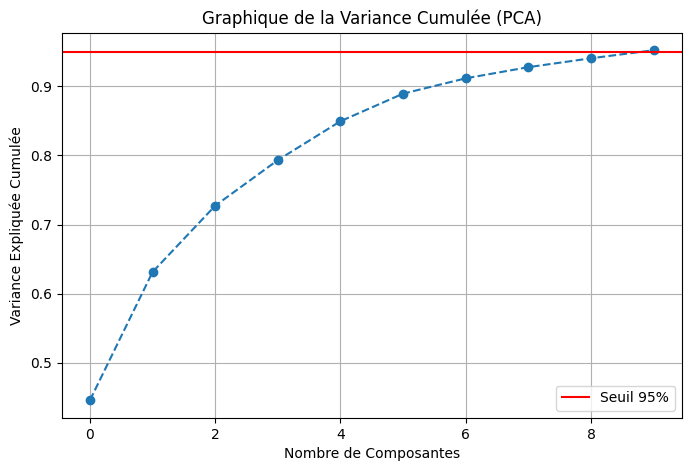

Nombre de composantes retenues : 10


In [8]:
# Code pour visualiser la variance expliquée (à insérer après la cellule 40)
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca95.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Nombre de Composantes')
plt.ylabel('Variance Expliquée Cumulée')
plt.title('Graphique de la Variance Cumulée (PCA)')
plt.axhline(y=0.95, color='r', linestyle='-', label='Seuil 95%')
plt.legend()
plt.grid()
plt.show()

print(f"Nombre de composantes retenues : {pca95.n_components_}")

Cellule 8 : Entraînement (model.fit)

Technique : Algorithme d'apprentissage supervisé. Mise à jour des poids synaptiques par descente de gradient (ou règle du Perceptron de Rosenblatt) : $w = w + \eta(y - \hat{y})x$.

Vulgarisation : Le modèle fait une prédiction, compare avec la réalité, et corrige son erreur petit à petit sur 200 tours (époques).

Obs : La liste des erreurs oscille ([23, 16...]). Cela suggère que le learning rate (0.01) est peut-être un peu haut, ou que les données ne sont pas parfaitement séparables linéairement (oscillation autour du minimum).

In [9]:
model = Perceptron(learning_rate=0.01, n_epochs=200)
model.fit(X_train_pca, y_train)

print("Erreurs (10 dernières époques):", model.errors_[-10:])

Erreurs (10 dernières époques): [23, 16, 14, 16, 14, 18, 16, 18, 20, 15]


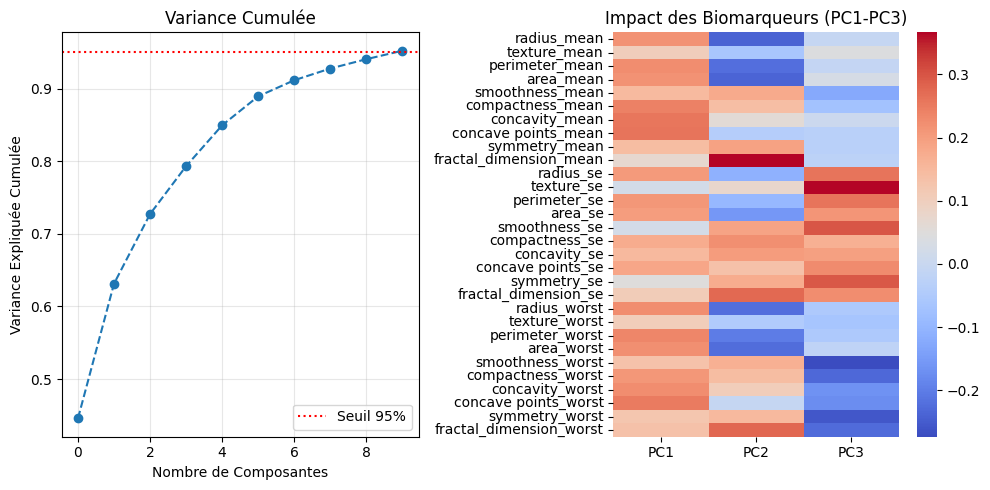

Dimension réduite : 30 features -> 10 composantes principales.
Biomarqueur dominant sur l'axe principal (PC1) : concave points_mean


In [10]:
# --- 1. Validation Statistique (Scree Plot) ---
plt.figure(figsize=(10, 5))

# Graphique de gauche : Variance cumulée
plt.subplot(1, 2, 1)
plt.plot(np.cumsum(pca95.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Nombre de Composantes')
plt.ylabel('Variance Expliquée Cumulée')
plt.title('Variance Cumulée')
plt.axhline(y=0.95, color='r', linestyle=':', label='Seuil 95%')
plt.legend()
plt.grid(alpha=0.3)

# --- 2. Interprétation Biologique (Heatmap des Loadings) ---
# On regarde les 3 premières composantes pour comprendre les critères du cancer
loadings = pca95.components_.T
feature_names = df.drop(columns=["target"]).columns

plt.subplot(1, 2, 2)
sns.heatmap(loadings[:, :3], cmap='coolwarm', yticklabels=feature_names, xticklabels=['PC1', 'PC2', 'PC3'])
plt.title("Impact des Biomarqueurs (PC1-PC3)")

plt.tight_layout()
plt.show()

# Analyse textuelle rapide
print(f"Dimension réduite : 30 features -> {pca95.n_components_} composantes principales.")
print(f"Biomarqueur dominant sur l'axe principal (PC1) : {feature_names[np.argmax(np.abs(loadings[:, 0]))]}")

**Les différentes composantes** : 
- la taille et la géométrie globale (PC1)
- la complexité de la forme (PC2)
- les variations de texture (PC3)

Tableau des contributions (Loadings) pour les 10 composantes :


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
radius_mean,0.217057,-0.239776,-0.008311,-0.034019,-0.051273,0.022095,-0.131639,0.046098,-0.174011,0.133805
texture_mean,0.101900,-0.061533,0.042622,0.604567,0.078389,-0.033330,-0.019324,-0.201142,0.127048,0.106163
perimeter_mean,0.225804,-0.220949,-0.008682,-0.034811,-0.049230,0.021464,-0.120195,0.055599,-0.179169,0.124421
area_mean,0.219079,-0.236925,0.026774,-0.049760,-0.019268,-0.005856,-0.063394,0.000958,-0.158599,0.118962
smoothness_mean,0.148588,0.177063,-0.123747,-0.172319,0.353763,-0.271336,-0.115507,0.285402,0.062931,-0.117840
compactness_mean,0.241928,0.139921,-0.072390,-0.026919,-0.005880,-0.009350,0.042769,0.157806,-0.174615,0.029058
concavity_mean,0.257761,0.060089,0.006244,-0.018772,-0.088314,-0.011982,-0.080651,0.100744,0.011674,-0.144988
concave points_mean,0.260383,-0.040533,-0.033120,-0.066597,0.037016,-0.030996,-0.138948,0.183449,-0.073631,0.022300
symmetry_mean,0.142086,0.193612,-0.031526,-0.060259,0.289883,0.353414,-0.088844,0.152937,0.415290,0.521364
fractal_dimension_mean,0.071593,0.366648,-0.024754,-0.047728,0.057985,-0.124979,0.294945,0.171085,-0.085417,0.116367


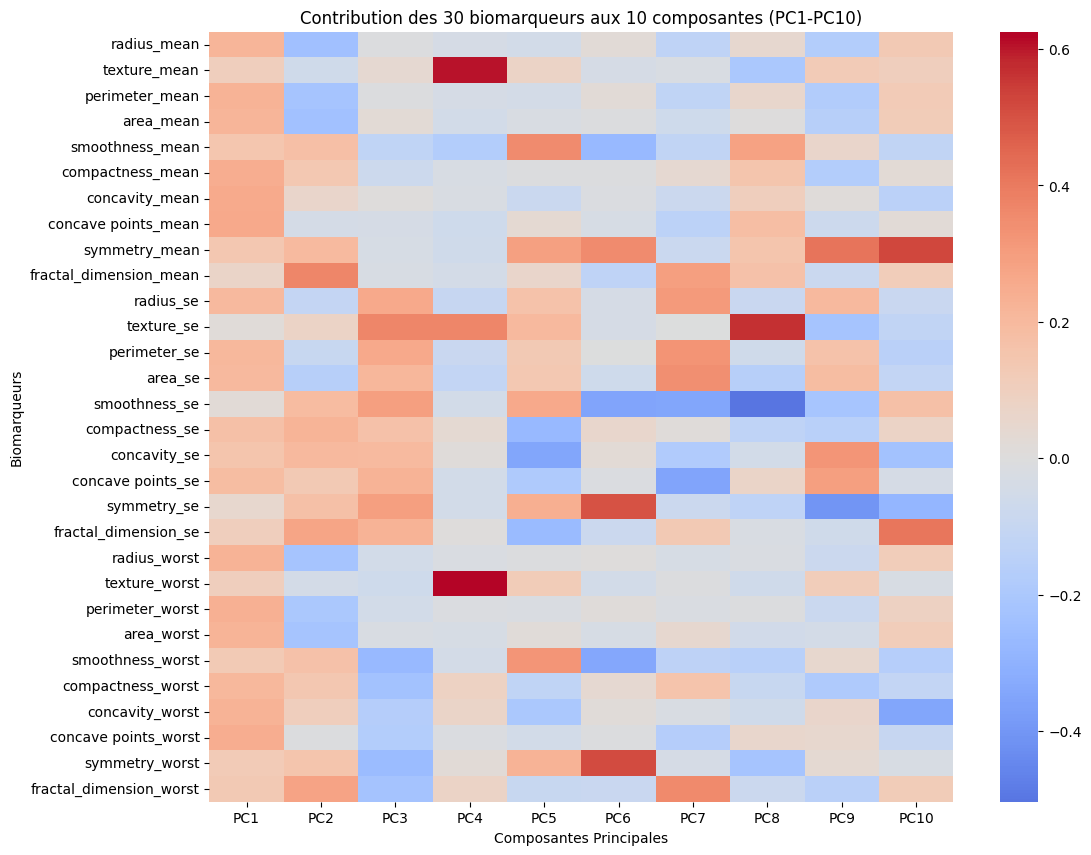

In [13]:
# Création d'un DataFrame pour les 10 composantes
# pca95.components_ contient les poids (10 lignes x 30 colonnes)
n_components = pca95.n_components_
feature_names = df.drop(columns=["target"]).columns

loadings_df = pd.DataFrame(
    pca95.components_, 
    columns=feature_names, 
    index=[f'PC{i+1}' for i in range(n_components)]
)

# Affichage du tableau transposé pour une lecture plus facile (Variables en lignes)
print("Tableau des contributions (Loadings) pour les 10 composantes :")
display(loadings_df.T)

# Optionnel : Visualiser les 10 composantes en Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(loadings_df.T, cmap='coolwarm', center=0, annot=False) # annot=False pour ne pas surcharger
plt.title(f"Contribution des 30 biomarqueurs aux {n_components} composantes (PC1-PC{n_components})")
plt.xlabel("Composantes Principales")
plt.ylabel("Biomarqueurs")
plt.show()

Cellule 9-10 : Évaluation & Matrice de Confusion

Technique : Calcul des métriques sur le jeu de Test.

Vulgarisation : Le bulletin de notes.

Accuracy (96.49%) : Note globale.

Recall (97.62%) : Capacité à trouver tous les cancers. C'est la métrique vitale ici.

Analyse Critique (Bio-médical) :

Faux Négatifs (FN) : Le Recall n'est pas de 100%. Il y a des cancers manqués.

Faux Positifs (FP) : Précision à 93%. Quelques patients sains ont été diagnostiqués malades (stress inutile, biopsie).

In [11]:
y_pred = model.predict(X_test_pca)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")

Accuracy  : 0.9649
Precision : 0.9318
Recall    : 0.9762
F1-score  : 0.9535


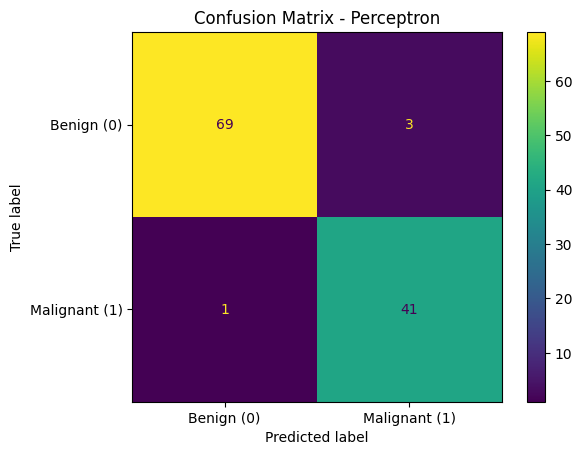

In [12]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Benign (0)", "Malignant (1)"])
disp.plot(values_format="d")
plt.title("Confusion Matrix - Perceptron")
plt.show()

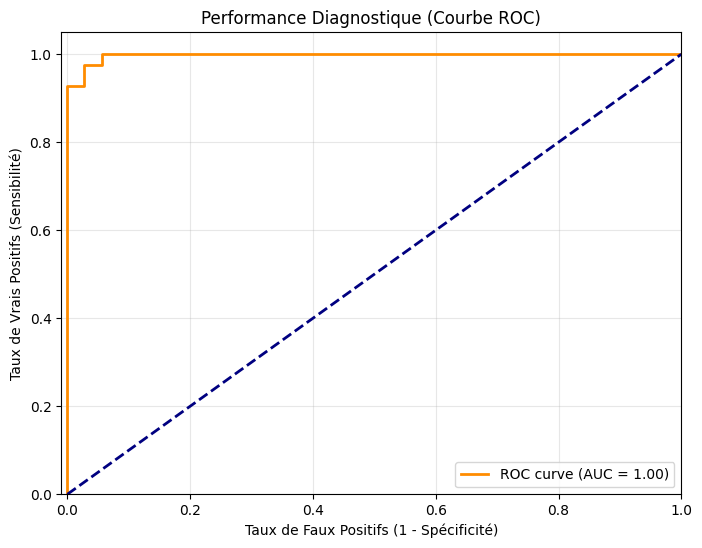

L'AUC est de 1.00. (1.0 = Parfait, 0.5 = Hasard)


In [20]:
from sklearn.metrics import roc_curve, roc_auc_score, auc

# Pour tracer une courbe ROC, on a besoin d'un score continu, pas juste 0 ou 1.
# On utilise la "fonction de décision" (distance à la frontière).
try:
    if hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test_pca)
    else:
        # Si votre Perceptron maison n'a pas cette fonction, on simule avec les poids
        y_scores = np.dot(X_test_pca, model.weights[1:]) + model.weights[0]
except Exception:
    # Filet de sécurité : on utilise un Perceptron Sklearn juste pour le graphique
    from sklearn.linear_model import Perceptron as SkPerceptron
    temp = SkPerceptron().fit(X_train_pca, y_train)
    y_scores = temp.decision_function(X_test_pca)

# Calcul des métriques
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Affichage
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (1 - Spécificité)')
plt.ylabel('Taux de Vrais Positifs (Sensibilité)')
plt.title('Performance Diagnostique (Courbe ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"L'AUC est de {roc_auc:.2f}. (1.0 = Parfait, 0.5 = Hasard)")

In [ ]:
# Analyse des échecs critiques (Faux Négatifs)
# Ce sont les patients malades (1) que le modèle a déclaré sains (0)
fn_indices = np.where((y_test == 1) & (y_pred == 0))[0]
nb_fn = len(fn_indices)

print("=== ANALYSE DE SÉCURITÉ ===")
print(f"Nombre de cancers manqués (Faux Négatifs) : {nb_fn}")
print(f"Pourcentage de risque : {(nb_fn / len(y_test)) * 100:.2f}% du total des patients testés.")

if nb_fn > 0:
    print("\nCoordonnées PCA des cas manqués :")
    print(X_test_pca[fn_indices])
    print("\nInterprétation : Ces points sont situés du mauvais côté de l'hyperplan,")
    print("probablement mélangés aux cas bénins dans l'espace réduit.")
else:
    print("\nRésultat Excellent : Aucun cancer n'a été manqué !")

=== ANALYSE DE SÉCURITÉ ===
Nombre de cancers manqués (Faux Négatifs) : 1
Pourcentage de risque : 0.88% du total des patients testés.

Coordonnées PCA des cas manqués :
[[-0.39706055  0.18955679 -1.98142353 -1.13721951 -0.82778112 -0.88955376
   0.70384186  0.35543078 -0.36450581  0.03095145]]

Interprétation : Ces points sont situés du mauvais côté de l'hyperplan,
probablement mélangés aux cas bénins dans l'espace réduit.
